# Astronomy Application

In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *

## import data, visualise

Average angular variance (in rad^2):  0.009240724037789944


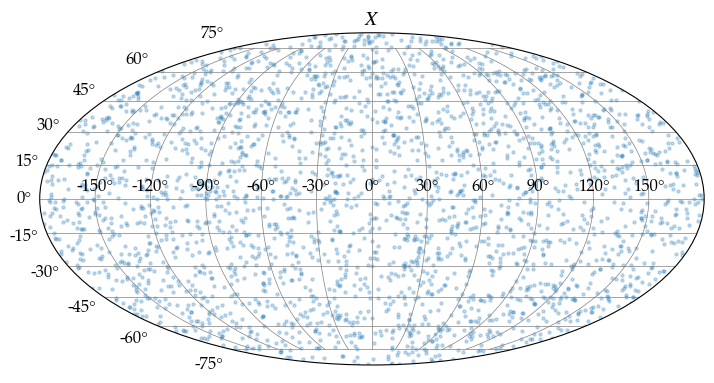

In [2]:
df = pd.read_csv('data/BATSE_4B.txt', header=None, sep='\s+', encoding='utf-8')

# Assume column 5 = RA, column 6 = Dec (in degrees)
ra = df[5].values
dec = df[6].values
phi = np.deg2rad(ra)           # longitude
theta = np.pi/2 - np.deg2rad(dec)  # colatitude
sphere = Hypersphere(dim=2)
X_sph = np.column_stack([theta, phi])
X = sphere.spherical_to_extrinsic(X_sph)

sigma2 = np.mean(np.power(df[9].values * np.pi/180.,2))
print('Average angular variance (in rad^2): ', sigma2)

# --- plot X
fig, ax = plt.subplots(1, 1, figsize=(10, 4), subplot_kw={'projection': 'mollweide'})
S2scatter(X, ax, color='C0', alpha=0.25)  # Changed axs[0] to axs[1]
ax.set_title('$X$')
plt.tight_layout()
plt.show()

## Density estimation

In [17]:
# Grid on S^2 (theta = colatitude, phi = longitude)
res_lat = 80
res_lon = 80
grid_theta, grid_phi = np.meshgrid(
    np.linspace(0, np.pi, res_lat),        # colatitude
    np.linspace(0, 2*np.pi, res_lon)      # longitude
)
X_grid = np.stack([
    np.sin(grid_theta) * np.cos(grid_phi),
    np.sin(grid_theta) * np.sin(grid_phi),
    np.cos(grid_theta)
], axis=-1).reshape(-1,3)


M = 10
rho = 0.05
X_grid, hat_f, hat_grad_f = density_estimate('S2', X, M, X_grid)
hat_score = - hat_grad_f / (hat_f[:, np.newaxis] + rho)

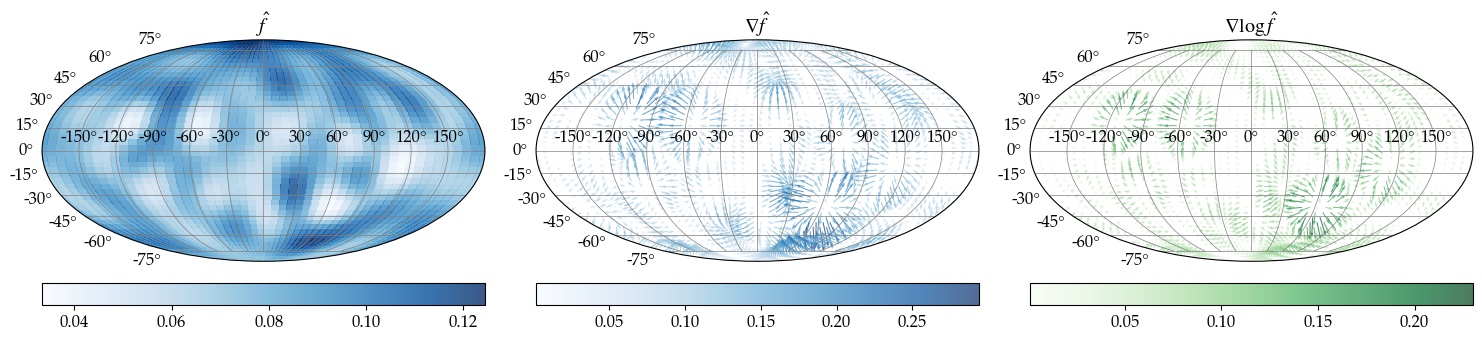

In [8]:
fig = S2plot_density_gradient_score(X,M,sigma2,rho,skip=2, mollwide=True); 
plt.show()


## Empirical Bayes denoising

In [9]:
delta = denoiser('S2', X, M, rho, sigma2, X)


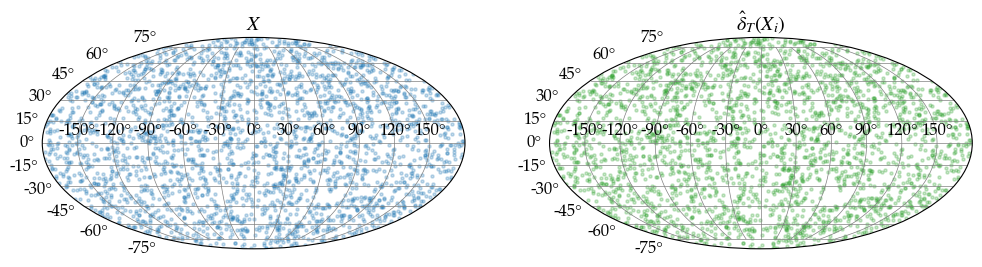

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 8), 
                        subplot_kw={'projection': 'mollweide'}
                        )

# Top-left plot: X
axs[ 0].grid(True, color='gray', lw=0.5)
axs[0].set_title('$X$')
S2scatter(X, ax=axs[ 0], color='C0', alpha=0.25)

# Top-right plot: $\hat{\delta}_T(X_i)$
axs[1].grid(True, color='gray', lw=0.5)
axs[1].set_title('$\\hat{\\delta}_T(X_i)$')
S2scatter(delta, ax=axs[ 1], color='C2', alpha=0.25)

if False:
    # Compute displacement vectors in spherical coordinates
    # Convert to Mollweide coordinates for plotting
    X_sph = sphere.extrinsic_to_spherical(X)
    delta_sph = sphere.extrinsic_to_spherical(delta)
    X_phi_mw = X_sph[:, 1] - np.pi
    X_theta_mw = np.pi/2 - X_sph[:, 0]


    delta_phi_mw = delta_sph[:, 1] - np.pi
    delta_theta_mw = np.pi/2 - delta_sph[:, 0]

    # Compute displacement
    u = delta_phi_mw - X_phi_mw
    v = delta_theta_mw - X_theta_mw

    # Subsample for clearer visualization
    stride = 1
    axs[1,1].quiver(X_phi_mw[::stride], X_theta_mw[::stride], 
            u[::stride], v[::stride], 
            color='red', alpha=0.6, scale=5, width=0.003)

    # Hide bottom-left and bottom-right axes
    axs[1, 0].axis('off')

    ax.grid(True, color='gray', lw=0.5)
    ax.set_title('Denoiser displacement: $X_i \\rightarrow \\hat{\\delta}_T(X)$')
    plt.tight_layout()
    plt.show()

------

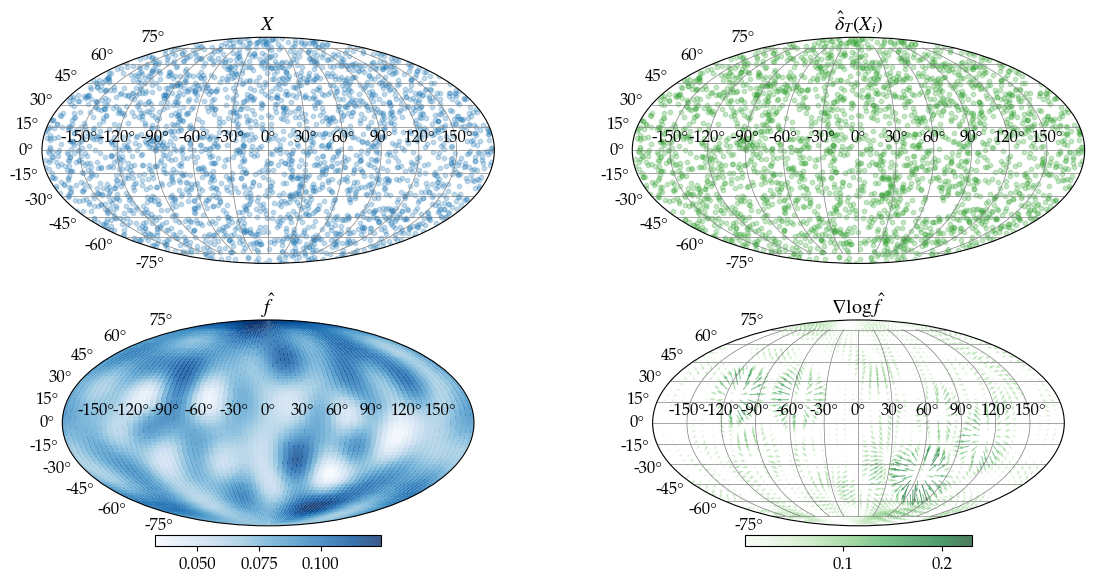

<Figure size 640x480 with 0 Axes>

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(12, 6), 
                        subplot_kw={'projection': 'mollweide'}
                        )
grid_phi_mw = (grid_phi - np.pi)          # longitude in [-pi, pi]
grid_theta_mw = (np.pi/2 - grid_theta)    # latitude in [-pi/2, pi/2]

# Top-left plot: X
axs[0, 0].grid(True, color='gray', lw=0.5)
axs[0, 0].set_title('$X$')
S2scatter(X, ax=axs[0, 0], color='C0', alpha=0.25, s=10)

# Top-right plot: $\hat{\delta}_T(X_i)$
axs[0, 1].set_title('$\\hat{\\delta}_T(X_i)$')
S2scatter(delta, ax=axs[0, 1], color='C2', alpha=0.25, s=10)
# ------ SECOND ROW

# Plot estimated density --------------------------------------------------
axs[1,0].set_title(r'$\hat f$')
im_f = axs[1,0].pcolormesh(grid_phi_mw, grid_theta_mw, 
                         hat_f.reshape(res_lat, res_lon),
                         alpha=0.8,shading='auto',cmap='Blues')
fig.colorbar(im_f, ax=axs[1,0], orientation='horizontal', fraction=0.05, pad=0.04)
# Plot score --------------------------------------------------
S2plot_quiver(fig, {'X' : X, 'M' : M}, rho, 'score', axs[1,1], skip = 1, grid_resolution = 50, scale = 5)
axs[1,1].set_title(r'$\nabla \log \hat f$')
plt.tight_layout()
plt.show()


ax.grid(True, color='gray', lw=0.5)
ax.set_title('Denoiser displacement: $X_i \\rightarrow \\hat{\\delta}_T(X_i)$')
plt.tight_layout()
plt.show()